# Tarea: Evaluación difusa de riesgo crediticio (sistema multiagente)
### Libreta 06: Sistemas multiagente

Reinterpreto los tres sistemas de inferencia difusa de la tarea 05 como una
**sociedad de agentes analistas**: cada agente evalúa el riesgo crediticio con su
propia estrategia (Mamdani, Tsukamoto o TSK) y un **agente coordinador** integra
sus dictámenes en una **solución global**.

Reutilizo el módulo `fis_models.py` (los mismos motores, variables y reglas de la
tarea 05). La diferencia con aquella libreta está en la **arquitectura**: paso de
tres modelos evaluados por separado a tres agentes cuyas opiniones se agregan.


## 1. De modelos a agentes

Un **agente** difuso encapsula un FIS y le da identidad y un rol: *percibe* a un
solicitante (sus tres variables), *delibera* con su motor de inferencia y *actúa*
emitiendo un dictamen de riesgo. Los tres agentes comparten la base de reglas
pero **razonan distinto**, así que pueden discrepar.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import fis_models as fm

class AgenteDifuso:
    """Agente analista: encapsula un FIS y emite un dictamen de riesgo [0,100]."""
    def __init__(self, nombre, fis):
        self.nombre = nombre
        self.fis = fis
    def dictaminar(self, solicitante):
        return self.fis.infer(solicitante)

sistemas = fm.build_credit_systems()
agentes = [AgenteDifuso(n, f) for n, f in sistemas.items()]
print("Agentes en el sistema:", [a.nombre for a in agentes])

# Dos solicitantes: uno de consenso y uno de discrepancia
ejemplos = {
    "Solicitante A (corto, monto bajo, mayor)": {"duration": 6, "credit_amount": 1200, "age": 55},
    "Solicitante B (medio, monto medio, adulto)": {"duration": 24, "credit_amount": 5000, "age": 40},
}
filas = []
for desc, x in ejemplos.items():
    fila = {"Caso": desc}
    for a in agentes:
        fila[a.nombre] = round(a.dictaminar(x), 1)
    filas.append(fila)
display(pd.DataFrame(filas).set_index("Caso"))


Agentes en el sistema: ['Mamdani', 'Tsukamoto', 'TSK']


,Mamdani,Tsukamoto,TSK
Caso,,,
"Solicitante A (corto, monto bajo, mayor)",15.5,36.2,9.4
"Solicitante B (medio, monto medio, adulto)",50.0,75.0,47.6


## 2. El coordinador y la solución global

Con el patrón **pizarra (*blackboard*)** de la libreta del curso, los agentes
depositan sus dictámenes y el **coordinador** los integra en una decisión
colectiva. Implemento dos formas de agregación:

- **Promedio de riesgo:** promedio el riesgo de los tres agentes y aplico el umbral.
- **Voto mayoritario:** cada agente clasifica (riesgo > umbral → `bad`) y gana la
  clase con al menos 2 de 3 votos.

Ninguna exige que un agente conozca la opinión de los demás: la decisión colectiva
resulta de la coordinación, no de un agente individual.


In [2]:
class Coordinador:
    """Integra los dictámenes de los agentes en una solución global."""
    def __init__(self, agentes, umbral=fm.THRESHOLD):
        self.agentes = agentes
        self.umbral = umbral
    def recoger(self, solicitante):
        return {a.nombre: a.dictaminar(solicitante) for a in self.agentes}
    def global_promedio(self, dictamenes):
        return float(np.mean(list(dictamenes.values())))
    def global_voto(self, dictamenes):
        votos = sum(1 for r in dictamenes.values() if r > self.umbral)
        return 1 if votos >= 2 else 0          # 1 = bad

coord = Coordinador(agentes)

# Dictámenes de cada agente para todo el dataset
df = pd.read_csv("data/german_credit.csv")
y_true = (df["class"] == "bad").astype(int).values
X = df[fm.FEATURES].to_dict("records")

riesgos = {a.nombre: np.array([a.dictaminar(x) for x in X]) for a in agentes}
riesgo_global = np.mean([riesgos[a.nombre] for a in agentes], axis=0)        # promedio
pred_global_prom = (riesgo_global > coord.umbral).astype(int)
votos = np.sum([(riesgos[a.nombre] > coord.umbral) for a in agentes], axis=0)
pred_global_voto = (votos >= 2).astype(int)

print("Dictámenes calculados para", len(df), "solicitantes.")
print("Dispersión media entre agentes (puntos de riesgo):",
      round(np.std([riesgos[a.nombre] for a in agentes], axis=0).mean(), 2))


Dictámenes calculados para 1000 solicitantes.
Dispersión media entre agentes (puntos de riesgo): 6.23


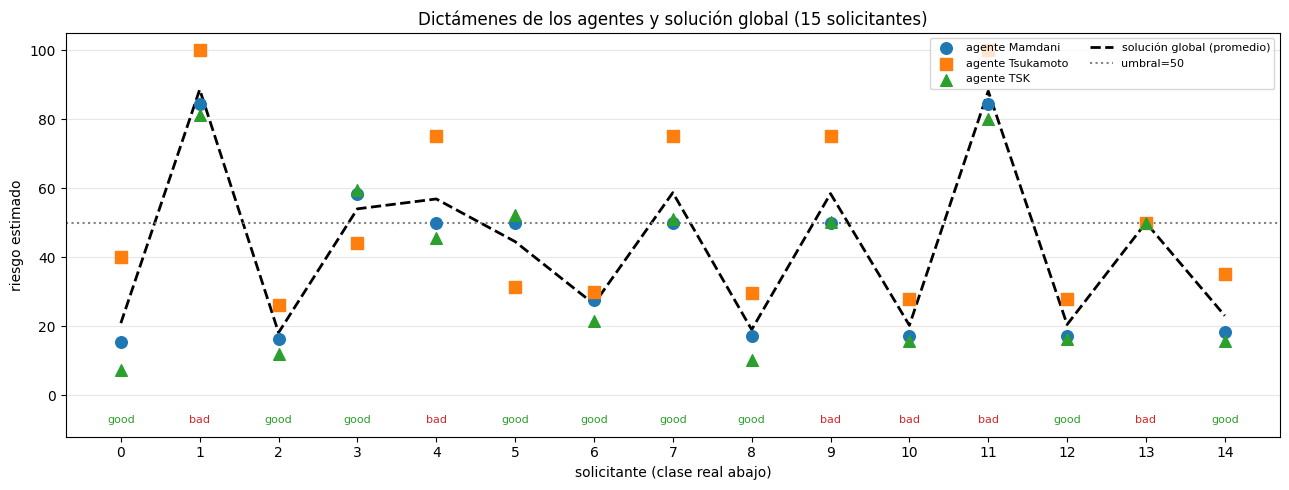

In [3]:
# Visualización: dictámenes de los agentes y solución global para 15 solicitantes
n = 15
x = np.arange(n)
fig, ax = plt.subplots(figsize=(13, 5))
marcadores = {"Mamdani": "o", "Tsukamoto": "s", "TSK": "^"}
for a in agentes:
    ax.scatter(x, riesgos[a.nombre][:n], marker=marcadores[a.nombre], s=70,
               label=f"agente {a.nombre}", zorder=3)
ax.plot(x, riesgo_global[:n], "k--", lw=2, label="solución global (promedio)", zorder=2)
ax.axhline(coord.umbral, color="gray", ls=":", label=f"umbral={coord.umbral:.0f}")
# clase real bajo cada caso
for i in range(n):
    ax.annotate(df["class"].iloc[i], (i, -8), ha="center", fontsize=8,
                color=("tab:red" if y_true[i] == 1 else "tab:green"))
ax.set_xticks(x); ax.set_xlabel("solicitante (clase real abajo)")
ax.set_ylabel("riesgo estimado"); ax.set_ylim(-12, 105)
ax.set_title("Dictámenes de los agentes y solución global (15 solicitantes)")
ax.legend(loc="upper right", ncol=2, fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 3. Evaluación: agentes vs. solución teórica vs. solución global

La **solución teórica** es la etiqueta real del dataset (`good`/`bad`). Comparo
contra ella a cada agente individual y a las dos soluciones globales, con las
mismas métricas de la tarea 05 (la *balanced accuracy* da la lectura honesta por
el desbalance 70/30).


In [4]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             recall_score, f1_score)

pred_agentes = {a.nombre: (riesgos[a.nombre] > coord.umbral).astype(int) for a in agentes}
todas = dict(pred_agentes)
todas["Global (promedio)"] = pred_global_prom
todas["Global (voto)"] = pred_global_voto

def metricas(yp):
    return {
        "Accuracy": accuracy_score(y_true, yp),
        "Balanced acc.": balanced_accuracy_score(y_true, yp),
        "Recall (bad)": recall_score(y_true, yp, zero_division=0),
        "F1 (bad)": f1_score(y_true, yp, zero_division=0),
    }

tabla = pd.DataFrame({nombre: metricas(yp) for nombre, yp in todas.items()}).T
print(f"Solución teórica: {y_true.sum()} 'bad' / {len(y_true)} (baseline trivial acc = {1-y_true.mean():.3f})")
display(tabla.round(3))

# Acuerdo de cada agente con la solución global (voto)
print("\nAcuerdo de cada agente con la solución global (voto):")
for a in agentes:
    ac = np.mean(pred_agentes[a.nombre] == pred_global_voto)
    print(f"  {a.nombre:10}: {ac*100:.1f}%")


Solución teórica: 300 'bad' / 1000 (baseline trivial acc = 0.700)


,Accuracy,Balanced acc.,Recall (bad),F1 (bad)
Mamdani,0.669,0.553,0.263,0.323
Tsukamoto,0.675,0.533,0.177,0.246
TSK,0.687,0.549,0.203,0.280
Global (promedio),0.672,0.536,0.197,0.265
Global (voto),0.676,0.545,0.217,0.286



Acuerdo de cada agente con la solución global (voto):
  Mamdani   : 96.5%
  Tsukamoto : 97.7%
  TSK       : 95.3%


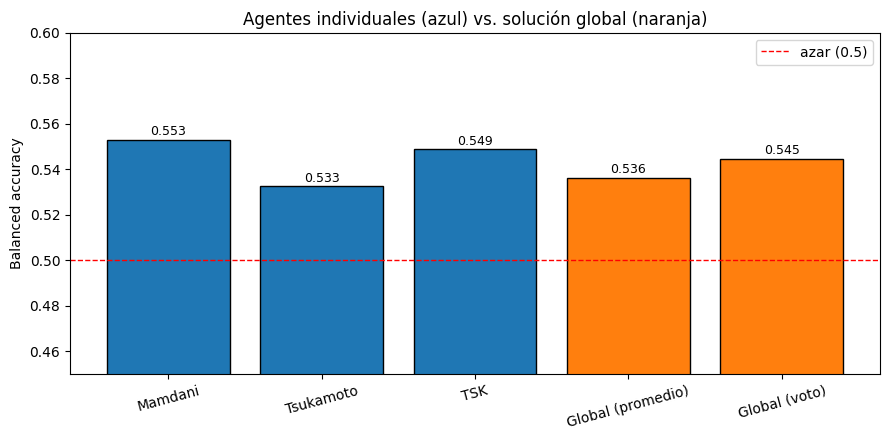

In [5]:
# Balanced accuracy: agentes vs soluciones globales
fig, ax = plt.subplots(figsize=(9, 4.5))
nombres = list(todas.keys())
vals = [balanced_accuracy_score(y_true, todas[n]) for n in nombres]
colores = ["tab:blue", "tab:blue", "tab:blue", "tab:orange", "tab:orange"]
barras = ax.bar(nombres, vals, color=colores, edgecolor="black")
ax.axhline(0.5, color="red", ls="--", lw=1, label="azar (0.5)")
ax.set_ylabel("Balanced accuracy"); ax.set_ylim(0.45, 0.6)
ax.set_title("Agentes individuales (azul) vs. solución global (naranja)")
for b, v in zip(barras, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)
ax.legend(); plt.xticks(rotation=15); plt.tight_layout(); plt.show()


## 4. Discusión técnica

**La solución global no supera a los agentes individuales.** Las soluciones
globales (balanced accuracy ≈ 0.54–0.55) quedan *entre* los agentes, cerca de la
mediana de sus desempeños. El motivo es la **baja diversidad**: los tres agentes
comparten las mismas variables y la misma base de reglas, y solo cambian en el
mecanismo de defuzzificación. Sus dictámenes están correlacionados (dispersión
media de unos 6 puntos de riesgo), así que la agregación no añade información,
solo promedia ruido parecido.

**Aun así, el SMA aporta tres propiedades de la decisión colectiva:**

- **Robustez:** la solución global ahorra tener que apostar de antemano por el
  "mejor" agente, que no conocemos sin las etiquetas. Da un desempeño estable,
  cercano a la mediana, sin el riesgo de quedarse con el peor modelo.
- **Tolerancia a fallos:** si un agente fallara o diera un dictamen anómalo, el
  voto mayoritario y el promedio amortiguan su efecto. Es la propiedad que la
  libreta del curso ilustra con el quórum parcial.
- **Reducción de varianza:** agregar suaviza las idiosincrasias de cada motor.

**Cuándo la agregación sí superaría a los individuos.** El teorema *No Free Lunch*
apunta la respuesta: la inteligencia colectiva rinde cuando los agentes son
**diversos e independientes**. Para que este SMA mejorara, los agentes tendrían
que mirar el problema desde ángulos distintos, cada uno con **variables o reglas
diferentes** (uno sobre el historial crediticio, otro sobre la capacidad de pago),
o ponderar su voto por una **reputación** estimada a partir de su acierto
histórico. Con agentes redundantes, como aquí, el consenso iguala a sus miembros
pero no los mejora.

**Conclusión.** Reinterpretar los FIS como sistema multiagente no cambia la
información disponible; cambia la **forma de decidir**, de elegir un modelo a
coordinar opiniones. El resultado es una decisión más robusta y tolerante a
fallos, y su margen de mejora depende de cuán diversos sean los agentes que la
componen.
